# Heart Disease Prediction - Model Training
## MLOps Assignment 1

This notebook demonstrates:
- Feature engineering and preprocessing
- Training multiple classification models
- Hyperparameter tuning with GridSearchCV
- Model evaluation with cross-validation
- MLflow experiment tracking

In [1]:
# Import required libraries
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from src.data_processing.preprocessor import load_data, preprocess_data
from src.models.train import train_models, evaluate_model

warnings.filterwarnings('ignore')
%matplotlib inline

print('Libraries imported successfully!')

/Users/dparsail/Desktop/M.Tech/Sem-2/MLOps/Assignments/heart-disease-mlops/.venv/lib/python3.12/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


Libraries imported successfully!


## 1. Load and Preprocess Data

In [2]:
# Load dataset
df = load_data('../data/heart_disease.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

INFO:src.data_processing.preprocessor:Loading data from ../data/heart_disease.csv
INFO:src.data_processing.preprocessor:Data loaded successfully. Shape: (303, 14)
INFO:src.data_processing.preprocessor:Missing values: 6


Dataset shape: (303, 14)

First few rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Preprocess and split data
X_train, X_test, y_train, y_test, preprocessor = preprocess_data(df, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTarget distribution in training set:")
print(pd.Series(y_train).value_counts())

# Save preprocessor
preprocessor.save('../models/preprocessor.pkl')
print("\n✓ Preprocessor saved")

INFO:src.data_processing.preprocessor:Starting data preprocessing...
INFO:src.data_processing.preprocessor:Features shape: (303, 13)
INFO:src.data_processing.preprocessor:Target distribution:
target
0    164
1    139
Name: count, dtype: int64
INFO:src.data_processing.preprocessor:Train set size: 242
INFO:src.data_processing.preprocessor:Test set size: 61
INFO:src.data_processing.preprocessor:Fitting preprocessor...
INFO:src.data_processing.preprocessor:Preprocessor fitted successfully
INFO:src.data_processing.preprocessor:Data preprocessing completed successfully
INFO:src.data_processing.preprocessor:Preprocessor saved to ../models/preprocessor.pkl


Training set size: (242, 13)
Test set size: (61, 13)

Target distribution in training set:
0    131
1    111
Name: count, dtype: int64

✓ Preprocessor saved


## 2. Train Multiple Models with MLflow Tracking

In [4]:
# Train models with experiment tracking
results = train_models(
    X_train, X_test, y_train, y_test,
    experiment_name="heart-disease-prediction",
    models_dir="../models"
)

print("\n" + "="*60)
print("Model Training Completed!")
print("="*60)

2026/05/09 15:47:40 INFO mlflow.tracking.fluent: Experiment with name 'heart-disease-prediction' does not exist. Creating a new experiment.
INFO:src.models.train:
INFO:src.models.train:Training Logistic Regression
INFO:src.models.train:============================================================
INFO:src.models.train:Performing hyperparameter tuning...
INFO:src.models.train:Evaluating Logistic Regression...
INFO:src.models.train:Logistic Regression Performance:
INFO:src.models.train:  Test Accuracy: 0.8689
INFO:src.models.train:  Test Precision: 0.8125
INFO:src.models.train:  Test Recall: 0.9286
INFO:src.models.train:  Test F1-Score: 0.8667
INFO:src.models.train:  Test ROC-AUC: 0.9578
INFO:src.models.train:  CV ROC-AUC: 0.8917 (+/- 0.0456)
INFO:src.models.train:✓ Logistic Regression training completed
INFO:src.models.train:
INFO:src.models.train:Training Random Forest
INFO:src.models.train:============================================================
INFO:src.models.train:Performing hyp


Model Training Completed!


## 3. Compare Model Performance

In [5]:
# Extract metrics for comparison
model_names = [name for name in results.keys() if name not in ['best_model_name', 'best_model_score']]

comparison_data = []
for name in model_names:
    metrics = results[name]['metrics']
    comparison_data.append({
        'Model': name,
        'Test Accuracy': metrics['test_accuracy'],
        'Test Precision': metrics['test_precision'],
        'Test Recall': metrics['test_recall'],
        'Test F1': metrics['test_f1'],
        'Test ROC-AUC': metrics['test_roc_auc'],
        'CV ROC-AUC': metrics['cv_roc_auc_mean']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test ROC-AUC', ascending=False)

print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))


Model Performance Comparison:
              Model  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC  CV ROC-AUC
      Random Forest       0.885246        0.838710     0.928571 0.881356      0.961039    0.893003
Logistic Regression       0.868852        0.812500     0.928571 0.866667      0.957792    0.891726
                SVM       0.885246        0.862069     0.892857 0.877193      0.946970    0.889102
  Gradient Boosting       0.852459        0.827586     0.857143 0.842105      0.898268    0.875383


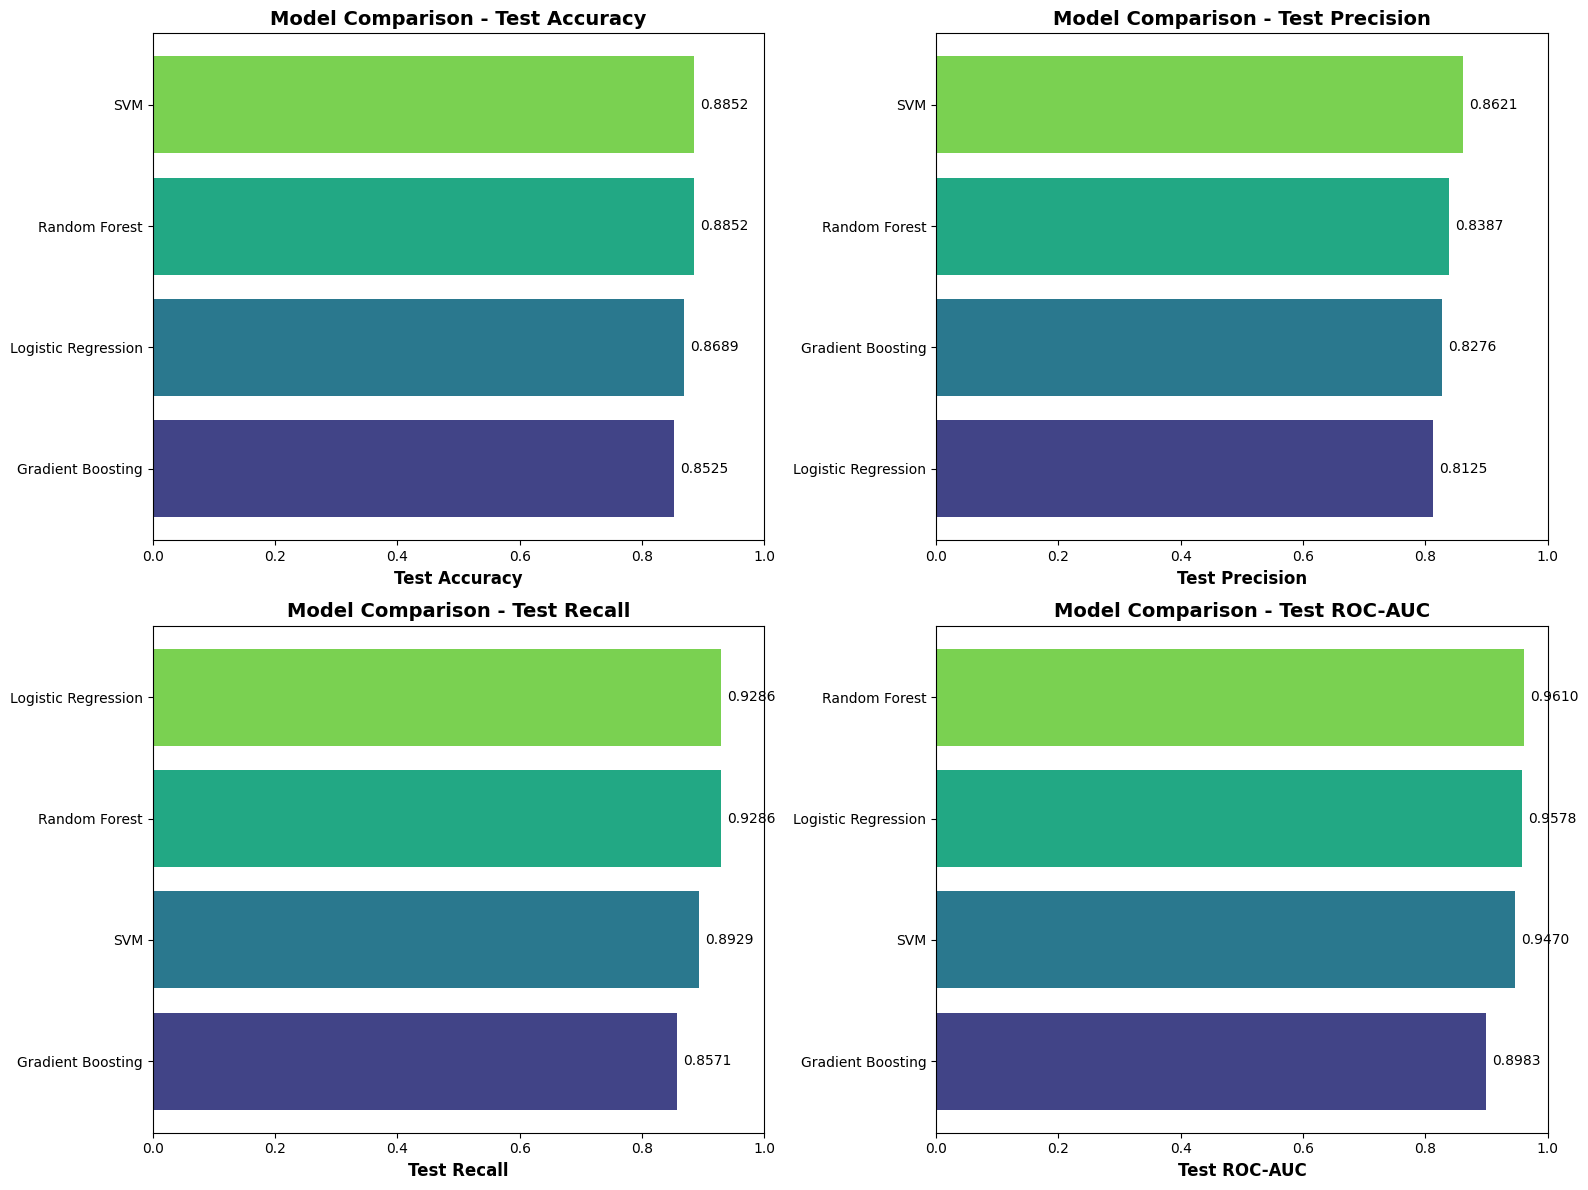

In [6]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test ROC-AUC']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    comparison_df_sorted = comparison_df.sort_values(metric, ascending=True)
    
    ax.barh(comparison_df_sorted['Model'], comparison_df_sorted[metric], 
           color=sns.color_palette('viridis', len(model_names)))
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'Model Comparison - {metric}', fontsize=14, fontweight='bold')
    ax.set_xlim([0, 1])
    
    # Add value labels
    for i, v in enumerate(comparison_df_sorted[metric]):
        ax.text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.savefig('../screenshots/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Best Model Summary

In [7]:
# Display best model information
best_model_name = results['best_model_name']
best_model_score = results['best_model_score']

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"ROC-AUC Score: {best_model_score:.4f}")
print(f"{'='*60}")

print(f"\nBest Hyperparameters:")
for param, value in results[best_model_name]['best_params'].items():
    print(f"  {param}: {value}")

print(f"\nFull Metrics:")
for metric, value in results[best_model_name]['metrics'].items():
    print(f"  {metric}: {value:.4f}")


BEST MODEL: Random Forest
ROC-AUC Score: 0.9610

Best Hyperparameters:
  max_depth: None
  min_samples_leaf: 4
  min_samples_split: 2
  n_estimators: 100

Full Metrics:
  train_accuracy: 0.9091
  test_accuracy: 0.8852
  train_precision: 0.9406
  test_precision: 0.8387
  train_recall: 0.8559
  test_recall: 0.9286
  train_f1: 0.8962
  test_f1: 0.8814
  train_roc_auc: 0.9796
  test_roc_auc: 0.9610
  cv_roc_auc_mean: 0.8930
  cv_roc_auc_std: 0.0429


Exception ignored in: <function ResourceTracker.__del__ at 0x1092ba7a0>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10731a7a0>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/